### Monitoring Employee Agent on LangSmith

In [30]:
import os
import json
from dotenv import load_dotenv, find_dotenv
from evals_tools import RetrieverTools  # tools wrapper
from IPython.display import Image, display
from typing import Literal

from langsmith import Client
from langsmith import evaluate
from langsmith import traceable

from langchain_ollama import ChatOllama
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

In [22]:
LANGSMITH_API_KEY = os.getenv("LANGSMITH_API_KEY")
_ = load_dotenv(find_dotenv())

**LangGraph State Schema: to track overall information of the application**

In [3]:
class AgentState(MessagesState):
    query: str

***Instantiate Tools***

In [23]:
retriever = RetrieverTools()

@tool
def lexical_search(query: str) -> list:
    """BM25 keyword search with CrossEncoder reranking. Use for exact keyword matches."""
    results = retriever.lexical_search(query)
    return [str(r['document'].page_content) for r in results]

@tool
def dense_search(query: str) -> list:
    """Dense vector search with LLM compression and reranking. Use for semantic search."""
    results = retriever.dense_search(query)
    return [str(r['page_content']) for r in results]

@tool
def graph_search(query: str) -> list:
    """Graph traversal retrieval using metadata relationships. Use for related roles and departments."""
    results = retriever.graph_search(query)
    return [str(doc.page_content) for doc in results]  # serialize to strings

tools = [lexical_search, dense_search, graph_search]
tools_by_name = {tool.name: tool for tool in tools}

Initializing RetrieverTools...
Loaded 1000 documents from '/mnt/c/Users/emman/chicago_employee_data/clean_data/employee_data.csv' 


Setting up BM25 index...
Extracting docs from documents...

Tokenizing corpus for BM25...



Building BM25 index:   0%|          | 0/1000 [00:00<?, ?it/s]

BM25 index ready with 1000 documents... 


Setting up Graph Retriever...
In-memory store created with 1000 enriched documents

All retrievers ready!


***Initialize the LLM, enforcing tool use***

In [6]:
llm = ChatOllama(model="qwen3-coder-next:cloud")
llm_with_tools = llm.bind_tools(tools, tool_choice='any')

***System message components***

In [7]:
persona = "You are an expert HR data analyst specializing in municipal employee records and organizational structures.\n"

instruction = "Answer questions about Chicago city employee data by ALWAYS using ALL THREE retrieval tools before giving a final answer.\n"

context = (
    "You have access to three retrieval tools and must call all three for every query:\n"
    "1. lexical_search: for exact keyword matches on names, job titles, and departments.\n"
    "2. dense_search: for contextual compression using LLM extraction, for the semantic understanding of the query.\n"
    "3. graph_search: for finding related roles, departments, and organizational relationships.\n"
    "Do NOT stop after one tool. Always call all three tools and combine their results.\n"
)

data_format = (
    "After calling all three tools, combine and deduplicate the results by employee name. "
    "Present your final answer clearly with employee name, job title, department, full time or part time, and salary. "
    "Only include employees that appear in the tool results. Do NOT invent or assume any employee data. "
    "Exclude employees whose department does not match the query. "
    "Do not give a final answer until all three tools have been called.\n"
)

audience = "The responses are designed for analysts and administrators who need quick, accurate insights from Chicago city employee records.\n"

tone = "The tone should be professional, concise, and data-driven.\n"

sys_msg = SystemMessage(content=persona + instruction + context + data_format + audience + tone)

***LLM Node with System Prompt***

In [8]:
def llm_assistant(state: AgentState):
    """LLM decides whether to call a tool or not"""
    return {
        "messages": [
            llm_with_tools.invoke(
                [sys_msg] + state["messages"]
            )
        ]
    }

***Tool handler node***

* After the LLM makes a decision, we need to execute the ```chosen tool```.

* The ```tool_handler``` node executes the tool by iterating through tool calls, get the actual ```tool name``` and run the tool to get an ```observation```.

In [9]:
def tool_handler(state: AgentState):
    """Performs the tool call."""
    
    # List for tool messages
    result = []
    
    # Iterate through tool calls, get tool, observe and create a tool message
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append({"role": "tool", "content" : observation, "tool_call_id": tool_call["id"]})
    
    # Add it to our messages
    return {"messages": result}

***Conditional Routing***

Our agent needs to decide when to ```continue using tools and when to stop```. This ```conditional routing``` function directs the agent to either ```continue or terminate```.

In [10]:
def should_continue(state: AgentState) -> Literal["tool_handler", "__end__"]:
    messages = state["messages"]
    last_message = messages[-1]
    
    if last_message.tool_calls:
        for tool_call in last_message.tool_calls:
            if tool_call["name"] == "Done":
                return END
        return "tool_handler"
    
    return END  # return END when no tool calls instead of None

***Build Workflow graph, Add Nodes, Edges, and Memory***

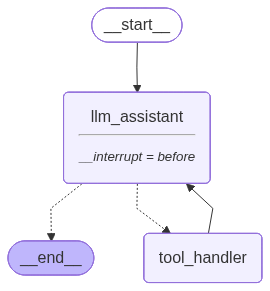

In [11]:
# Build workflow
graph_workflow = StateGraph(AgentState)

# Add nodes
graph_workflow.add_node("llm_assistant", llm_assistant)
graph_workflow.add_node("tool_handler", tool_handler)

# Add edges
graph_workflow.add_edge(START, "llm_assistant")
graph_workflow.add_conditional_edges(
    "llm_assistant",
    should_continue,
    {
        "tool_handler": "tool_handler",
        END: END,
    },
)
graph_workflow.add_edge("tool_handler", "llm_assistant")

# Memory
memory = MemorySaver()
graph = graph_workflow.compile(interrupt_before=["llm_assistant"], checkpointer=memory)

# Show Graph
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

***Run Query***

* We can see the graph is interrupted before the chat model responds.

In [12]:
query_1 = input("\nEnter query here: ")

# Thread
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream({"messages": [HumanMessage(content=query_1)]}, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()


Enter query here:  List some fire fighters in Chicago?


================================ Human Message =================================

List some fire fighters in Chicago?


In [13]:
state = graph.get_state(thread)
state

StateSnapshot(values={'messages': [HumanMessage(content='List some fire fighters in Chicago?', additional_kwargs={}, response_metadata={}, id='6237e80c-4062-4cb5-b760-3bc83224c154')]}, next=('llm_assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f131e7e-7481-6277-8000-c344b4c13dc3'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-04-06T18:39:11.266120+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f131e7e-7461-6747-bfff-41a71a271918'}}, tasks=(PregelTask(id='b0bd1f86-0bc9-6bfb-362c-52010aa2685c', name='llm_assistant', path=('__pregel_pull', 'llm_assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

***Now, we can directly apply a state update***

Remember, updates to the messages key will use the ```add_messages``` reducer:
* If we want to over-write the existing message, we can supply the message id.
* If we simply want to append to our list of messages, then we can pass a message without an id specified.

In [14]:
query_2 = input("\nEnter query here: ")

graph.update_state(
    thread,
    {"messages": [HumanMessage(content=query_2)]},
)


Enter query here:  Actually, list some investigators in Chicago


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f131e7f-e99e-6666-8001-c9fffbbc7961'}}

***Let's have a look***

* We called ```update_state``` with a new message.

* The ```add_messages reducer``` appends it to our state key -- messages.

In [15]:
new_state = graph.get_state(thread).values
for m in new_state['messages']:
    m.pretty_print()

================================ Human Message =================================

List some fire fighters in Chicago?
================================ Human Message =================================

Actually, list some investigators in Chicago


* Now, let's proceed with our ```agent```, simply by passing ```None``` and allowing it proceed from the ```current state```.

* We emit the ```current``` and then proceed to execute the ```remaining nodes```.

In [16]:
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Actually, list some investigators in Chicago
================================== Ai Message ==================================
Tool Calls:
  lexical_search (b38a03dd-63b3-4471-9bc3-a3ecca5985d8)
 Call ID: b38a03dd-63b3-4471-9bc3-a3ecca5985d8
  Args:
    query: investigator
  dense_search (6de3ea5d-dd2c-40f4-8e5c-a7e5c08263de)
 Call ID: 6de3ea5d-dd2c-40f4-8e5c-a7e5c08263de
  Args:
    query: investigators in Chicago city government
  graph_search (9fdd8e0d-e1e8-477f-8dd2-e71ac5a981bb)
 Call ID: 9fdd8e0d-e1e8-477f-8dd2-e71ac5a981bb
  Args:
    query: investigator roles in Chicago departments

[Lexical Search] Query: 'investigator'
Searching for: 'investigator'

Step 1: BM25 retrieval (getting 5 candidates)

Top-3 BM25 results (before reranking):


1. BM25 Score: 5.105
   name: ALVAREZ, ALFREDO
job_titles: PARKING INVESTIGATOR
department: DEPARTMENT OF FINANCE
full_or_part_time: F
salary_or_hourly: SALARY
ann

Now, we're back at the ```assistant```, which has our ```breakpoint```.

We can again pass ```None``` to proceed.

In [17]:
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================

['name: ALEXANDER, ROSS J\njob_titles: POLICE OFFICER (ASSIGNED AS EVIDENCE TECHNICIAN)\ndepartment: CHICAGO POLICE DEPARTMENT\nfull_or_part_time: F\nsalary_or_hourly: SALARY\nannual_salary: 128964.0\ntypical_hours: 36.40625\nhourly_rate: 44.2503125', 'name: ADAMS, TIMOTHY J\njob_titles: POLICE OFFICER (ASSIGNED AS DETECTIVE)\ndepartment: CHICAGO POLICE DEPARTMENT\nfull_or_part_time: F\nsalary_or_hourly: SALARY\nannual_salary: 144792.0\ntypical_hours: 36.40625\nhourly_rate: 44.2503125', 'name: ANDREWS, JENNY D\njob_titles: POLICE OFFICER (ASSIGNED AS DETECTIVE)\ndepartment: CHICAGO POLICE DEPARTMENT\nfull_or_part_time: F\nsalary_or_hourly: SALARY\nannual_salary: 127230.0\ntypical_hours: 36.40625\nhourly_rate: 44.2503125', 'name: ALVAREZ, JOSE M\njob_titles: POLICE OFFICER (ASSIGNED AS EVIDENCE TECHNICIAN)\ndepartment: CHICAGO POLICE DEPARTMENT\nfull_or_part_time: F\nsalary_or_hourly: SALARY\nannual_salary

### Evaluating Agent (Offline Evaluation Workflow)

***1. Create Groundtruth Dataset***

* Load Ground Truth Dataset (!head -n 20 ../groundtruth/groundtruth_dataset.json)

In [5]:
def groundtruth(data: str):
    with open(data, "r") as f:
        examples = json.load(f)

    print(f"{len(examples)} Groundtruth loaded successfully!")
    return examples

In [6]:
examples = groundtruth("../groundtruth/groundtruth_dataset.json")
print('-'*50, '\n')
print(examples[:5])

9000 Groundtruth loaded successfully!
-------------------------------------------------- 

[{'inputs': {'question': 'Do you know if AARON, JEFFERY M works full-time or part-time?'}, 'outputs': {'answer': {'name': 'AARON, JEFFERY M', 'job_titles': 'LIEUTENANT', 'department': 'CHICAGO POLICE DEPARTMENT', 'full_or_part_time': 'F', 'salary_or_hourly': 'SALARY', 'annual_salary': 165624.0, 'typical_hours': 36.40625, 'hourly_rate': 44.2503125}}, 'metadata': {'difficulty': 'easy', 'source': 'synthetic'}}, {'inputs': {'question': "I'm looking for AARON, JEFFERY M work hours: full-time or part-time?"}, 'outputs': {'answer': {'name': 'AARON, JEFFERY M', 'job_titles': 'LIEUTENANT', 'department': 'CHICAGO POLICE DEPARTMENT', 'full_or_part_time': 'F', 'salary_or_hourly': 'SALARY', 'annual_salary': 165624.0, 'typical_hours': 36.40625, 'hourly_rate': 44.2503125}}, 'metadata': {'difficulty': 'easy', 'source': 'synthetic'}}, {'inputs': {'question': 'Is AARON, JEFFERY M full-time or part-time?'}, 'output

***2. Insert Groundtruth Dataset into LangSmith with Inputs and Reference Output Pairs***

In [22]:
# Initialize LangSmith client
client = Client()

dataset = client.create_dataset(
    dataset_name="Chicago Employee Information",
    description="Dataset that gives information about Chicago Employees"
)

client.create_examples(
    dataset_id=dataset.id,
    examples=examples
)

{'example_ids': ['2e7fa1f0-d842-4649-9ec9-5c80aedf0d67',
  '77e016e9-86af-4a4d-9bef-05cb76341b68',
  'e003449b-fed2-4cf4-949e-e57fb917d2f1',
  'ea16c60d-3b7f-4dad-a1da-a15faf4aad80',
  'f4b8b22c-31ed-481a-8ce4-0b83119902b5',
  '291dfe6e-4343-4fad-bf62-20fb1774b194',
  '2e96addb-7b07-4800-8d89-7966d71bbf19',
  '0bd8b604-bef2-4c9b-9c0a-2938ab8cbfe6',
  '07cad9a0-0be5-40ec-9d4a-9715d143ed89',
  '0144885a-aa2d-44b5-8859-4a0d5049ca47',
  'e0b59111-551a-4336-95bd-2d9f0fa13864',
  '2496386f-30b3-4627-afe0-133f0258e54f',
  'c283d97b-b4ca-4303-8eb9-e40c76bae59f',
  'f128ef79-4fef-486c-8608-f6d437bc3afa',
  '4d16876d-8396-48b6-8ccf-594efeceeed0',
  'f2177e4b-8929-411e-80b2-afd9b6aad7cf',
  'ee06a10d-ae53-4784-a7d9-bcdf81ff85e9',
  'b8c1e24a-bbbf-48fc-b1b3-ab6e288c9c75',
  '8092139e-0ad3-48e4-80ea-cf93798ed00a',
  '702e7fc4-47d2-43bd-820e-f7b1a4026084',
  'f371e61d-2da1-4be4-9c5b-c09f8c7c31d7',
  'd0736076-262f-4020-8965-0e7eed6805b7',
  '9a4cf16a-dfac-46e2-8598-8e43a444e050',
  '13ff57a4-0500-41

**3. Query Dataset**

In [23]:
datasets = client.list_datasets()

In [24]:
datasets = client.list_datasets(dataset_name="Chicago Employee Information")
print(datasets)

<generator object Client.list_datasets at 0x76274cbf8f40>


In [25]:
example_1 = client.list_examples(dataset_id="0002d831-cd0f-431a-ad49-60a812cbe6d7")
print(example_1)

<generator object Client.list_examples at 0x7627953dc940>


***4. Evaluation Metrics***

* Pipeline Output for Agentic Application 

In [34]:
client = Client()
llm = ChatOllama(model="gpt-oss:20b-cloud")

@traceable
def generate_output(inputs: dict) -> dict:
    """Generate answer using all three retrievers as context."""
    question = inputs["question"]
    
    # Get context from all three retrievers
    lexical_context = lexical_search.invoke({"query": question})
    dense_context = dense_search.invoke({"query": question})
    graph_context = graph_search.invoke({"query": question})
    
    # Combine all contexts
    combined_context = "\n".join([
        "=== Lexical Search Results ===",
        "\n".join(lexical_context),
        "=== Dense Search Results ===",
        "\n".join(dense_context),
        "=== Graph Search Results ===",
        "\n".join(graph_context),
    ])
    
    # Generate answer using LLM with context
    sys_msg = SystemMessage(content=(
        "You are an expert HR data analyst for Chicago city employee records. "
        "Use ONLY the provided context to answer the question. "
        "Return a JSON object with these fields: name, job_titles, department, "
        "full_or_part_time, salary_or_hourly, annual_salary, typical_hours, hourly_rate. "
        "Do NOT invent any data not in the context."
    ))
    
    human_msg = HumanMessage(content=(
        f"Context:\n{combined_context}\n\n"
        f"Question: {question}\n\n"
        "Answer in JSON format only."
    ))
    
    response = llm.invoke([sys_msg, human_msg])
    try:
        parsed = json.loads(response.content)
    except:
        parsed = {"raw": response.content}

    return {"answer": parsed}

In [25]:
type(examples)

list

In [35]:
# view examples input questions
for ex in examples:
    question = ex['inputs']['question']
    print(question)

Do you know if AARON, JEFFERY M works full-time or part-time?
I'm looking for AARON, JEFFERY M work hours: full-time or part-time?
Is AARON, JEFFERY M full-time or part-time?
Can you find the employees with hourly rate 44.2503125
Can you tell me anyone who works as a LIEUTENANT in the CHICAGO POLICE DEPARTMENT?
Do you know who works as a LIEUTENANT in the CHICAGO POLICE DEPARTMENT?
Do you know or identify the employee who works in CHICAGO POLICE DEPARTMENT, earns 165624.0, and has the title LIEUTENANT?
Please identify a LIEUTENANT working full-time in CHICAGO POLICE DEPARTMENT earning 165624.0?
Which employee matches: LIEUTENANT, CHICAGO POLICE DEPARTMENT, salary 165624.0, full-time status F?
Do you know what is the job title of AARON, KARINA?
Do you know the job title of AARON, KARINA?
Help me find what department does AARON, KARINA work in?
Please identify or find the employees with hourly rate 44.2503125
Which employee earns 140454.0 annually?
Do you know which employee earns 140454

In [36]:
# Generate and log Outputs from LLM(Agents App)
@traceable(name="Chicago Employee App")
def traced_generate(inputs):
    return generate_output(inputs)

for ex in examples:
    traced_generate(ex["inputs"])


[Lexical Search] Query: 'Do you know if AARON, JEFFERY M works full-time or part-time?'
Searching for: 'Do you know if AARON, JEFFERY M works full-time or part-time?'

Step 1: BM25 retrieval (getting 5 candidates)

Top-3 BM25 results (before reranking):


1. BM25 Score: 14.285
   name: AARON, JEFFERY M
job_titles: LIEUTENANT
department: CHICAGO POLICE DEPARTMENT
full_or_part_time: F
salary_or_hourly: SALARY
annual_salary: 165624.0
typical_hours: 36.40625
hourly_rate: 44.2503125

2. BM25 Score: 5.256
   name: AMBROZIAK, AARON J
job_titles: FIREFIGHTER/PARAMEDIC
department: CHICAGO FIRE DEPARTMENT
full_or_part_time: F
salary_or_hourly: SALARY
annual_salary: 122376.0
typical_hours: 36.40625
hourly_rate: 44.2503125

3. BM25 Score: 5.134
   name: ABERO, AARON
job_titles: PARKING ENFORCEMENT AIDE
department: DEPARTMENT OF FINANCE
full_or_part_time: F
salary_or_hourly: SALARY
annual_salary: 49056.0
typical_hours: 36.40625
hourly_rate: 44.2503125
Step 2: Reranking with CrossEncoder 


 Top-3 

KeyboardInterrupt: 

In [37]:
# Define an evaluator
def correct(inputs: dict, outputs: dict, reference_outputs: dict) -> bool:
    return outputs["answer"] == reference_outputs["answer"]

In [ ]:
# Client.evaluate() and evaluate() behave the same.
results = evaluate(
    traced_generate,
    data="Chicago Employee Information",
    evaluators=[correct],
    experiment_prefix="retriever_eval",  # optional, experiment name prefix
    description="Testing the baseline system.",  # optional, experiment description
    metadata={"retrievers": "lexical + dense + graph"}
)

View the evaluation results for experiment: 'retriever_eval-6b46a2ce' at:
https://smith.langchain.com/o/f0078a98-c6b7-4bbc-a866-5dd7a9f7a15d/datasets/f776372f-12d5-497b-8f3b-26cbb312f2c0/compare?selectedSessions=3d306cb7-2eee-4b29-a430-02da9b6a00a5




0it [00:00, ?it/s]


[Lexical Search] Query: 'Please identify Find the employee with hourly rate 44.2503125'
Searching for: 'Please identify Find the employee with hourly rate 44.2503125'

Step 1: BM25 retrieval (getting 5 candidates)

Top-3 BM25 results (before reranking):


1. BM25 Score: 2.047
   name: AGUILAR, DANIEL A
job_titles: LIBRARY ASSOCIATE - HOURLY
department: CHICAGO PUBLIC LIBRARY
full_or_part_time: P
salary_or_hourly: HOURLY
annual_salary: 111814.14905940594
typical_hours: 20.0
hourly_rate: 32.3

2. BM25 Score: 2.047
   name: AGUIRRE, VICTOR A
job_titles: LIBRARY ASSOCIATE - HOURLY
department: CHICAGO PUBLIC LIBRARY
full_or_part_time: P
salary_or_hourly: HOURLY
annual_salary: 111814.14905940594
typical_hours: 20.0
hourly_rate: 32.3

3. BM25 Score: 2.047
   name: ANTOLIN, ALYSSA
job_titles: LIBRARY CLERK - HOURLY
department: CHICAGO PUBLIC LIBRARY
full_or_part_time: P
salary_or_hourly: HOURLY
annual_salary: 111814.14905940594
typical_hours: 20.0
hourly_rate: 22.82
Step 2: Reranking with Cro